In [4]:
ls 

sched_ecdf_overlay.pdf
sched_ecdf_overlay.png
scheduler_times-decomposed_100ms_1core.csv
scheduler_times-decomposed_100ms_apiserver.csv
scheduler_times-decomposed_100ms.csv
scheduler_times-decomposed_10ms_1core.csv
scheduler_times-decomposed_10ms_apiserver.csv
scheduler_times-decomposed_10ms.csv
scheduler_times-decomposed_1s_1core.csv
scheduler_times-decomposed_1s_apiserver.csv
scheduler_times-decomposed_1s.csv
scheduler_times-decomposed_200ms_1core.csv
scheduler_times-decomposed_200ms_apiserver.csv
scheduler_times-decomposed_200ms.csv
scheduler_times-decomposed_50ms_1core.csv
scheduler_times-decomposed_50ms_apiserver.csv
scheduler_times-decomposed_50ms.csv
Untitled4.ipynb


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 510 samples, median=63.6ms, p99=327.3ms
  [OK]   Local 1core / 10ms — 514 samples, median=75.8ms, p99=400.3ms
  [OK]   Local APIserver / 10ms — 528 samples, median=48.2ms, p99=374.5ms
  [OK]   Local / 50ms — 185 samples, median=27.8ms, p99=188.6ms
  [OK]   Local 1core / 50ms — 179 samples, median=25.2ms, p99=122.5ms
  [OK]   Local APIserver / 50ms — 163 samples, median=24.1ms, p99=98.1ms
  [OK]   Local / 100ms — 142 samples, median=17.3ms, p99=80.1ms
  [OK]   Local 1core / 100ms — 143 samples, median=16.2ms, p99=229.6ms
  [OK]   Local APIserver / 100ms — 142 samples, median=16.0ms, p99=255.6ms
  [OK]   Local / 200ms — 111 samples, median=12.7ms, p99=71.4ms
  [OK]   Local 1core / 200ms — 115 samples, median=12.6ms, p99=80.8ms
  [OK]   Local APIserver / 200ms — 111 samples, median=13.3ms, p99=155.5ms
  [OK]   Local / 1s — 130 samples, median=9.7ms, p99=53.8ms
  [OK]   Local 1core / 1s — 143 samples, median

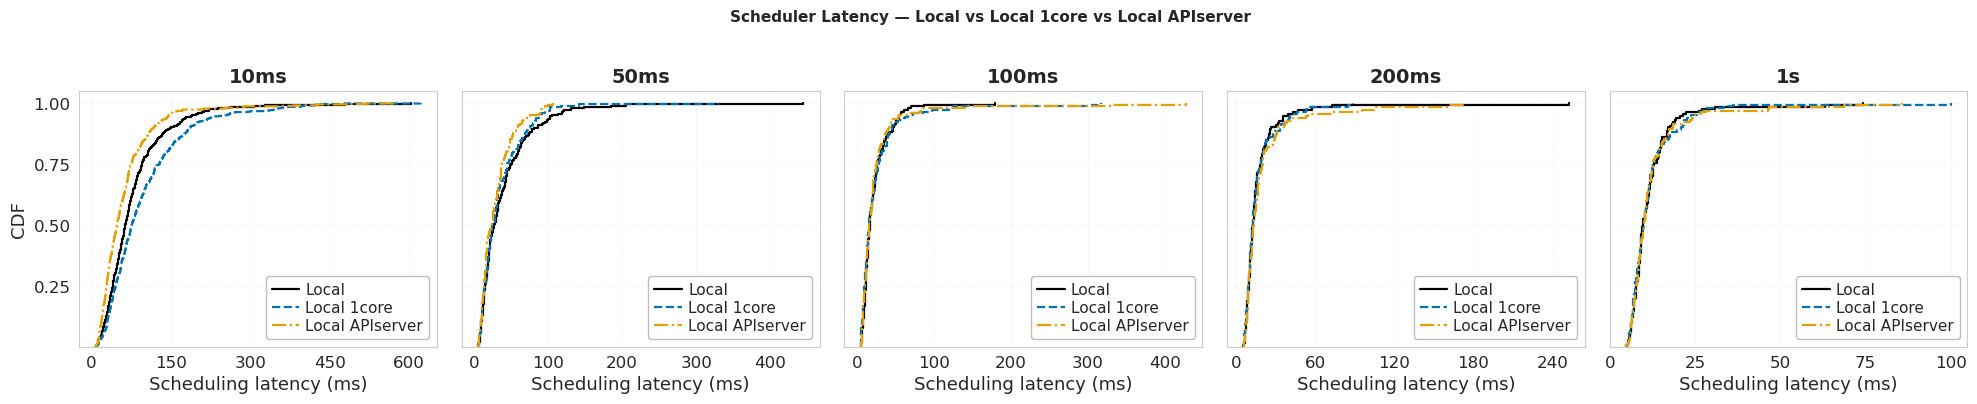

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#000000", "#0072B2", "#E69F00", "#CC0000"]
LINESTYLES = ["-",       "--",      "-.",      ":"]
LABELS     = ["Local",  "Local 1core", "Local APIserver"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"scheduler_times-decomposed_{d}.csv") for d in DELAYS
    },
    
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"scheduler_times-decomposed_{d}_1core.csv") for d in DELAYS
    },
    "Local APIserver": {
        d: os.path.join(DATA_DIR, f"scheduler_times-decomposed_{d}_apiserver.csv") for d in DELAYS
    },
}

MODES = ["Local",  "Local 1core", "Local APIserver"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["scheduling_time_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {LABELS[i]} / {delay} — {len(data)} samples, "
              f"median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Scheduling latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Scheduler Latency — Local vs Local 1core vs Local APIserver",
    fontsize=11,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "sched_ecdf_overlay.pdf"
out_png = "sched_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
[OK] Local/10ms -> median=63.63ms | p99=327.30ms
[OK] Local 1core/10ms -> median=75.84ms | p99=400.27ms
[OK] Local APIserver/10ms -> median=48.23ms | p99=374.55ms
[OK] Local/50ms -> median=27.80ms | p99=188.60ms
[OK] Local 1core/50ms -> median=25.19ms | p99=122.55ms
[OK] Local APIserver/50ms -> median=24.08ms | p99=98.09ms
[OK] Local/100ms -> median=17.31ms | p99=80.07ms
[OK] Local 1core/100ms -> median=16.15ms | p99=229.64ms
[OK] Local APIserver/100ms -> median=16.02ms | p99=255.59ms
[OK] Local/200ms -> median=12.66ms | p99=71.40ms
[OK] Local 1core/200ms -> median=12.57ms | p99=80.77ms
[OK] Local APIserver/200ms -> median=13.34ms | p99=155.48ms
[OK] Local/1s -> median=9.73ms | p99=53.83ms
[OK] Local 1core/1s -> median=10.08ms | p99=35.06ms
[OK] Local APIserver/1s -> median=10.03ms | p99=62.24ms

===== P99 SUMMARY =====

10ms
  Local              : 327.30 ms
  Local 1core        : 400.27 ms
  Local APIserver    : 374.55 ms

50m

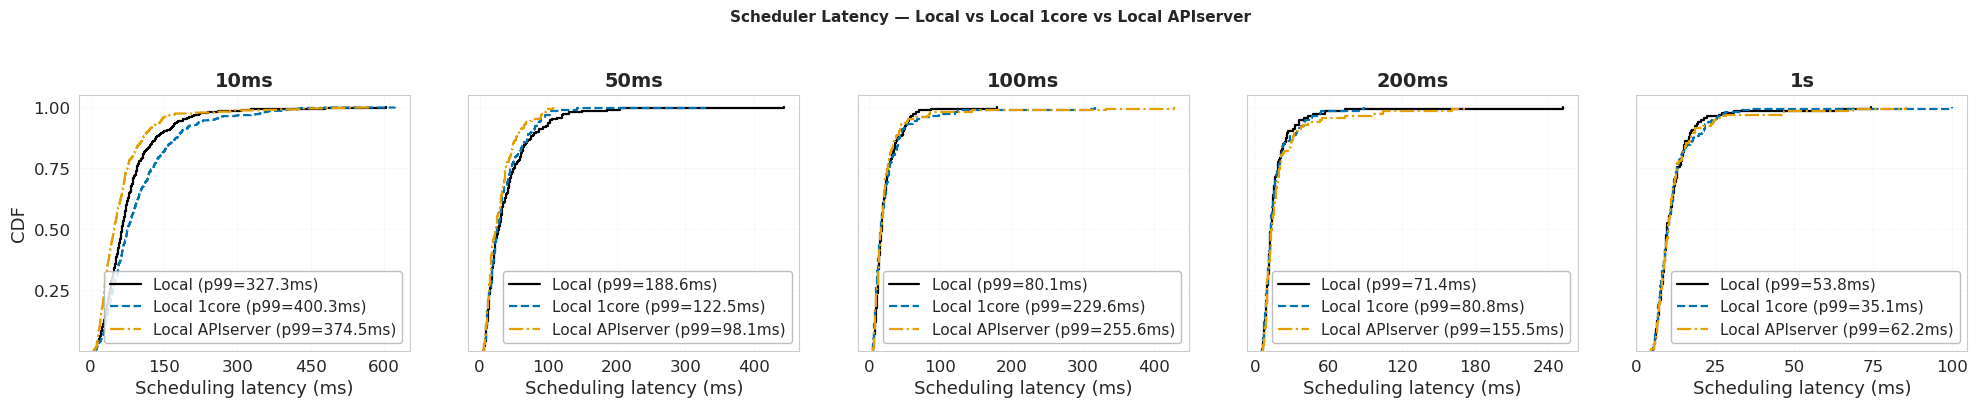

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── CONFIG ───────────────────────────────────────────────────────────
COLORS     = ["#000000", "#0072B2", "#E69F00", "#CC0000"]
LINESTYLES = ["-", "--", "-.", ":"]
LABELS     = ["Local", "Local 1core", "Local APIserver"]

DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"scheduler_times-decomposed_{d}.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"scheduler_times-decomposed_{d}_1core.csv") for d in DELAYS
    },
    "Local APIserver": {
        d: os.path.join(DATA_DIR, f"scheduler_times-decomposed_{d}_apiserver.csv") for d in DELAYS
    },
}

MODES = ["Local", "Local 1core", "Local APIserver"]

# ─── LOAD ─────────────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["scheduling_time_ms"].dropna()

# ─── STYLE AX ──────────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK FILES ───────────────────────────────────────────────────────
available_delays = [
    d for d in DELAYS
    if any(os.path.exists(FILES[m][d]) for m in MODES)
]

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé")

# ─── FIGURE ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(available_delays), figsize=(4 * len(available_delays), 4), sharey=True)
if len(available_delays) == 1:
    axes = [axes]

# ─── STORAGE P99 ───────────────────────────────────────────────────────
p99_results = {}

for c, delay in enumerate(available_delays):
    ax = axes[c]
    p99_results[delay] = {}

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)

        if data is None or len(data) == 0:
            print(f"[SKIP] {mode}/{delay}")
            continue

        p99 = data.quantile(0.99)
        median = data.median()
        p99_results[delay][mode] = p99

        print(f"[OK] {mode}/{delay} -> median={median:.2f}ms | p99={p99:.2f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=f"{LABELS[i]} (p99={p99:.1f}ms)"
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Scheduling latency (ms)")
    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(loc='lower right')
    style_ax(ax)

# ─── GLOBAL TITLE ──────────────────────────────────────────────────────
fig.suptitle(
    "Scheduler Latency — Local vs Local 1core vs Local APIserver",
    fontsize=11,
    fontweight='bold',
    y=1.02,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
plt.savefig("sched_ecdf_overlay.pdf", dpi=300, bbox_inches="tight")
plt.savefig("sched_ecdf_overlay.png", dpi=300, bbox_inches="tight")

# ─── SUMMARY TABLE P99 ────────────────────────────────────────────────
print("\n===== P99 SUMMARY =====")
for delay, modes in p99_results.items():
    print(f"\n{delay}")
    for mode, p99 in modes.items():
        print(f"  {mode:<18} : {p99:.2f} ms")

print("\n✓ Done")

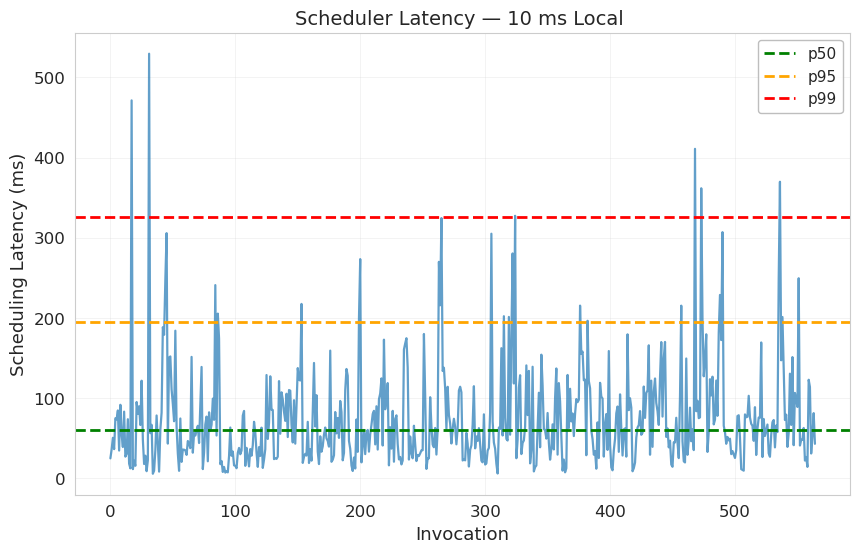

In [30]:
import matplotlib.pyplot as plt
import numpy as np

sched_10 = pd.read_csv("scheduler_times-10ms.csv")
# Récupérer les durées
durations = sched_10['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_10.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 10 ms Local ")
plt.savefig("scheduler_latencies_percentiles_10ms.pdf", format="pdf")
plt.show()

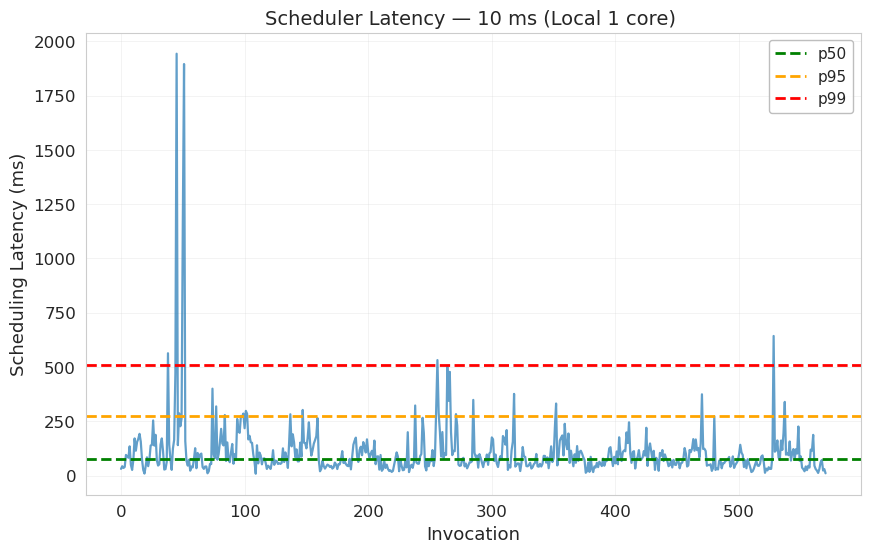

In [31]:
import matplotlib.pyplot as plt
import numpy as np

sched_10_core = pd.read_csv("scheduler_times-10ms_1core.csv")
# Récupérer les durées
durations = sched_10_core['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_10_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 10 ms (Local 1 core) ")
plt.savefig("scheduler_latencies_percentiles_10ms_1core.pdf", format="pdf")
plt.show()

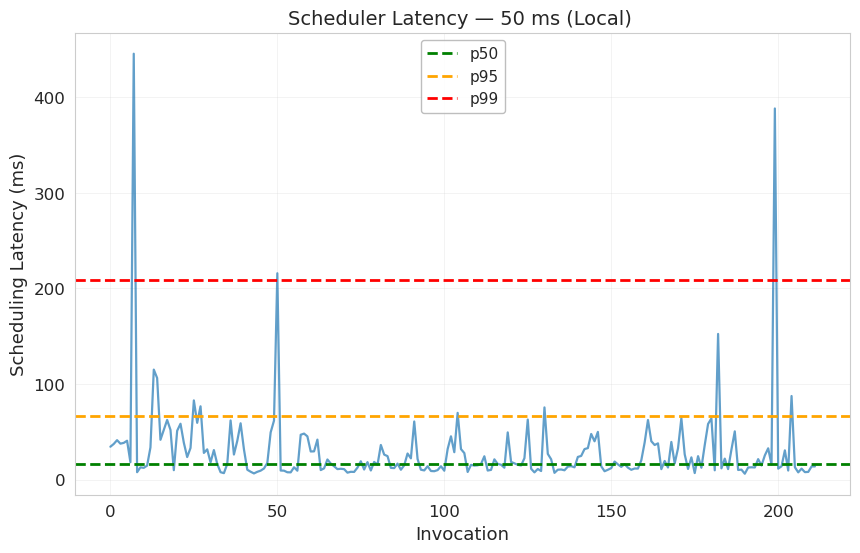

In [32]:
import matplotlib.pyplot as plt
import numpy as np

sched_50 = pd.read_csv("scheduler_times-50ms.csv")
# Récupérer les durées
durations = sched_50['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_50.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 50 ms (Local) ")
plt.savefig("scheduler_latencies_percentiles_50ms.pdf", format="pdf")
plt.show()

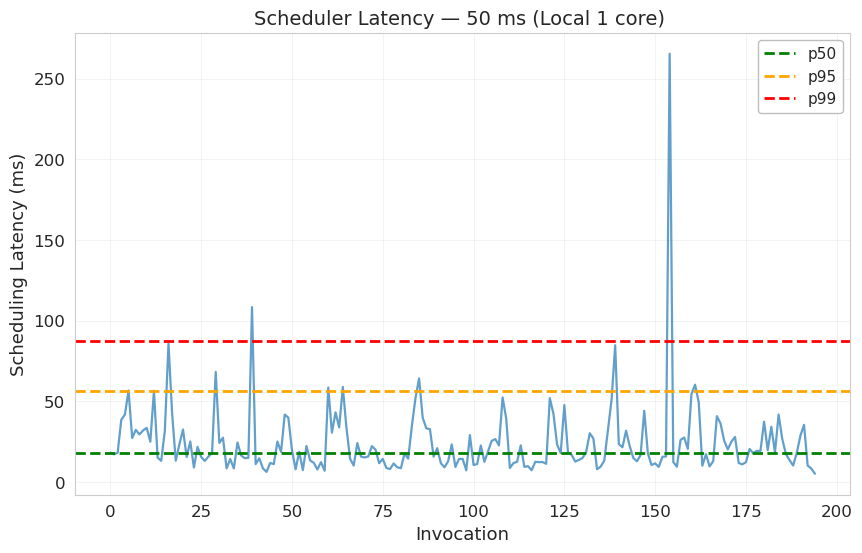

In [33]:
import matplotlib.pyplot as plt
import numpy as np

sched_50_core = pd.read_csv("scheduler_times-50ms_1core.csv")
# Récupérer les durées
durations = sched_50_core['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_50_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 50 ms (Local 1 core) ")
plt.savefig("scheduler_latencies_percentiles_50ms_core.pdf", format="pdf")
plt.show()

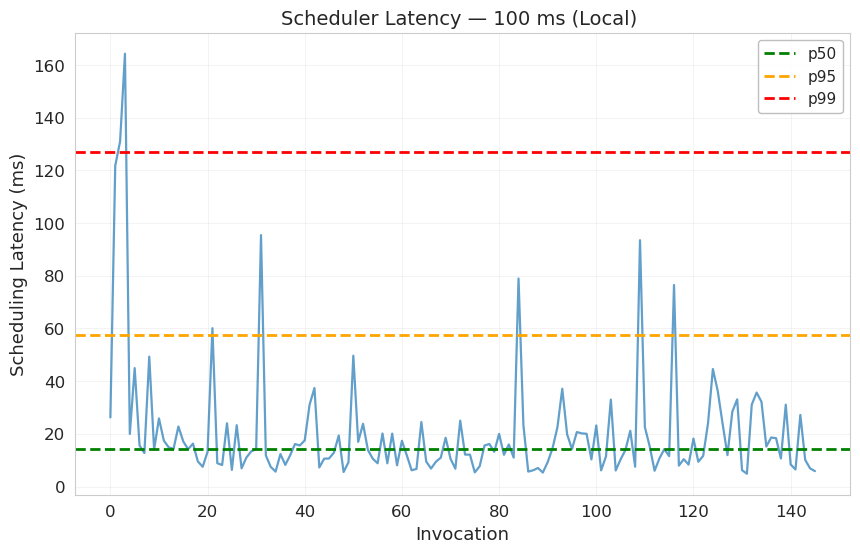

In [34]:
import matplotlib.pyplot as plt
import numpy as np

sched_100 = pd.read_csv("scheduler_times-100ms.csv")
# Récupérer les durées
durations = sched_100['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_100.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 100 ms (Local) ")
plt.savefig("scheduler_latencies_percentiles_100ms.pdf", format="pdf")
plt.show()

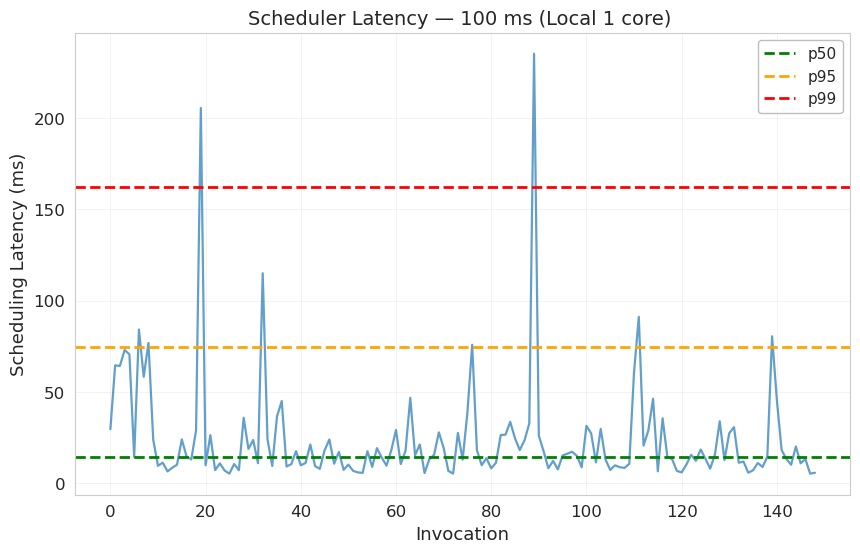

In [35]:
import matplotlib.pyplot as plt
import numpy as np

sched_100_core = pd.read_csv("scheduler_times-100ms_1core.csv")
# Récupérer les durées
durations = sched_100_core['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_100_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 100 ms (Local 1 core) ")
plt.savefig("scheduler_latencies_percentiles_100ms_1core.pdf", format="pdf")
plt.show()

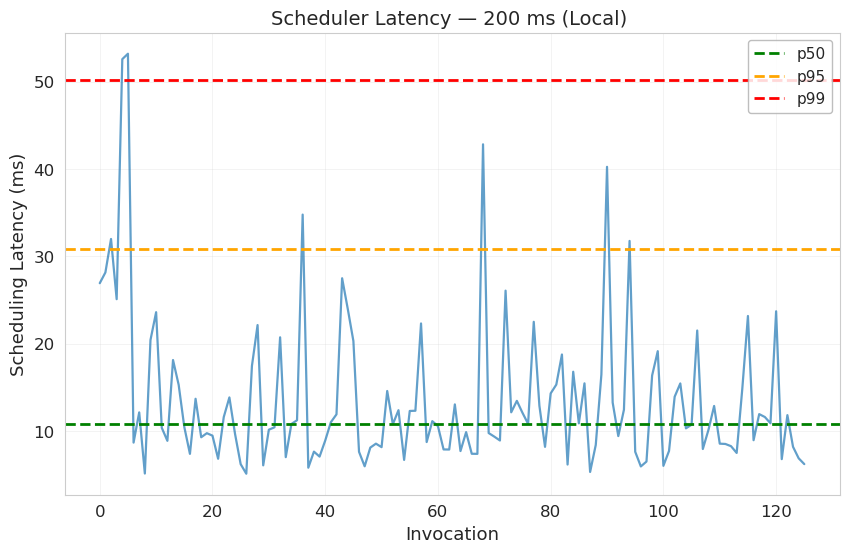

In [36]:
import matplotlib.pyplot as plt
import numpy as np

sched_200 = pd.read_csv("scheduler_times-200ms.csv")
# Récupérer les durées
durations = sched_200['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_200.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 200 ms (Local) ")
plt.savefig("scheduler_latencies_percentiles_200ms.pdf", format="pdf")
plt.show()

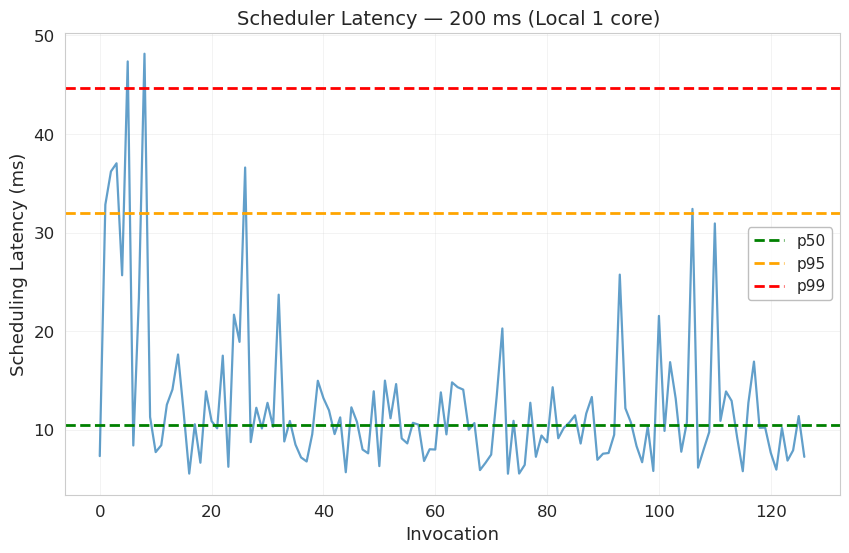

In [37]:
import matplotlib.pyplot as plt
import numpy as np

sched_200_core = pd.read_csv("scheduler_times-200ms_1core.csv")
# Récupérer les durées
durations = sched_200_core['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_200_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 200 ms (Local 1 core) ")
plt.savefig("scheduler_latencies_percentiles_200ms_core.pdf", format="pdf")
plt.show()

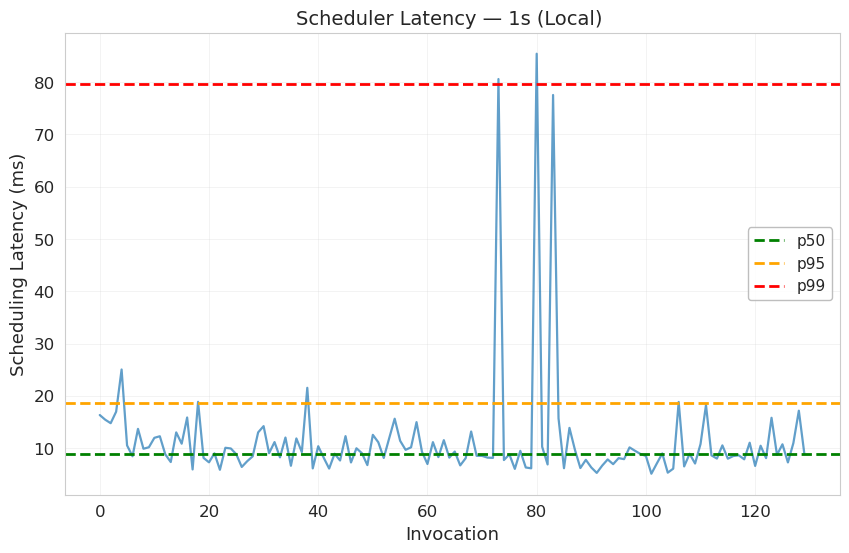

In [38]:
import matplotlib.pyplot as plt
import numpy as np

sched_1 = pd.read_csv("scheduler_times-1s.csv")
# Récupérer les durées
durations = sched_1['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_1.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 1s (Local) ")
plt.savefig("scheduler_latencies_percentiles_1.pdf", format="pdf")
plt.show()

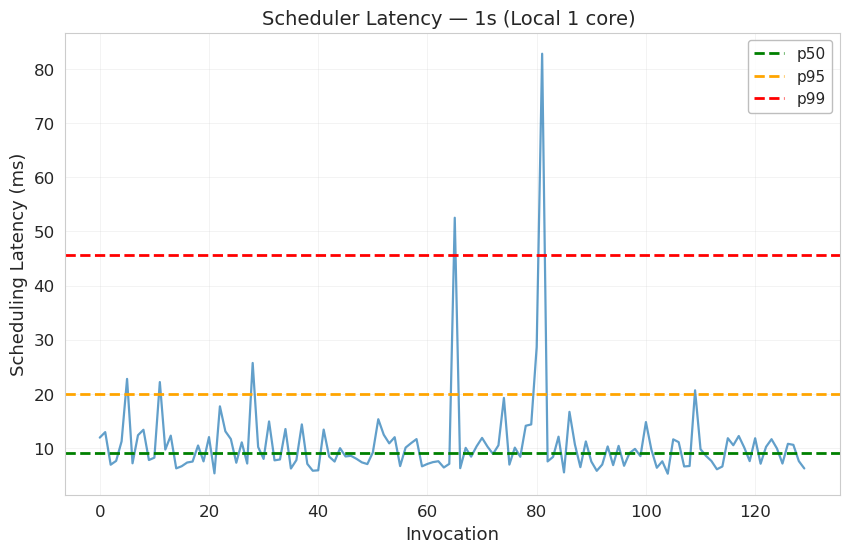

In [39]:
import matplotlib.pyplot as plt
import numpy as np

sched_1_core = pd.read_csv("scheduler_times-1s_1core.csv")
# Récupérer les durées
durations = sched_1_core['scheduling_time_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(sched_1_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("Scheduling Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("Scheduler Latency — 1s (Local 1 core) ")
plt.savefig("scheduler_latencies_percentiles_1_core.pdf", format="pdf")
plt.show()